geo        shape=(1000163, 5)  cols=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
customers  shape=(99441, 5)  cols=['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
orders     shape=(99441, 8)  cols=['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
reviews    shape=(99224, 7)  cols=['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- geo ---
Sem nulos

--- customers ---
Sem nulos

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64
CEPs únicos: 19015
   geolo

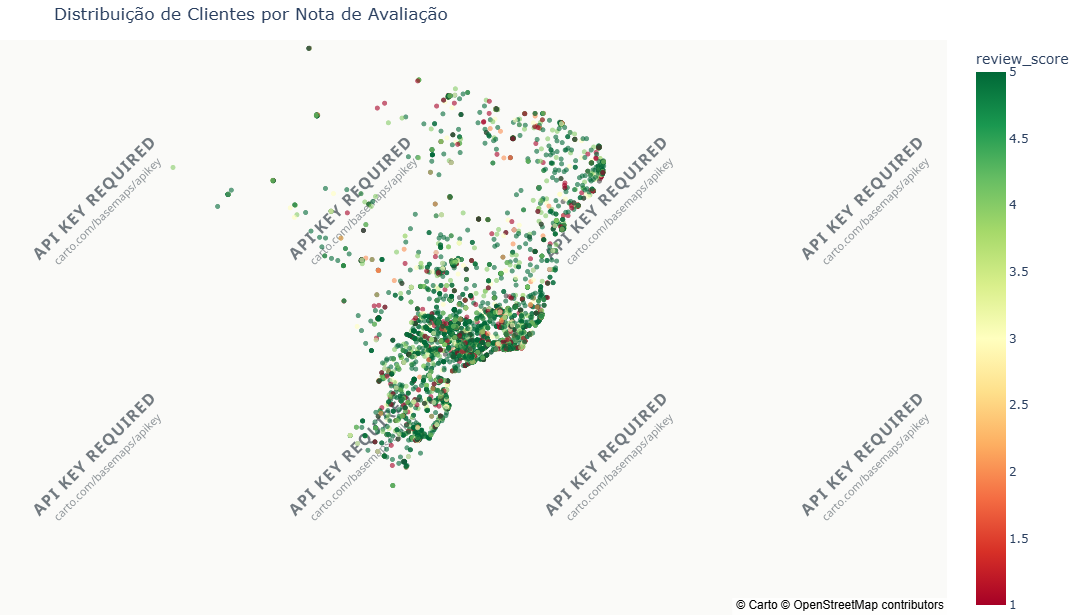

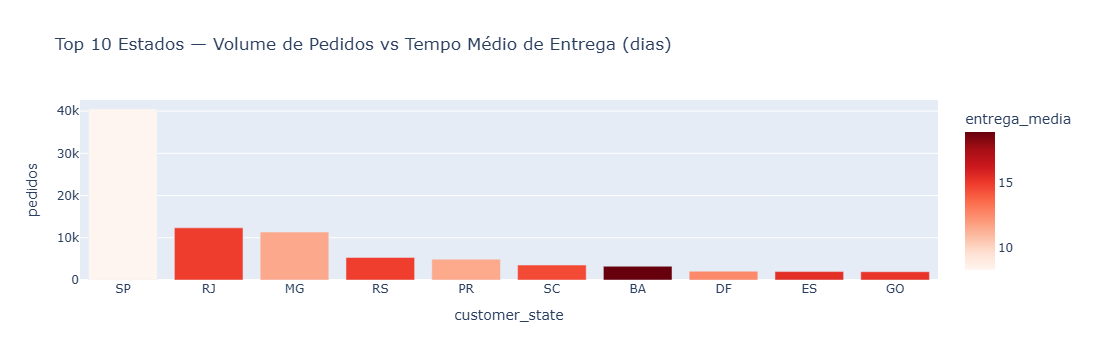

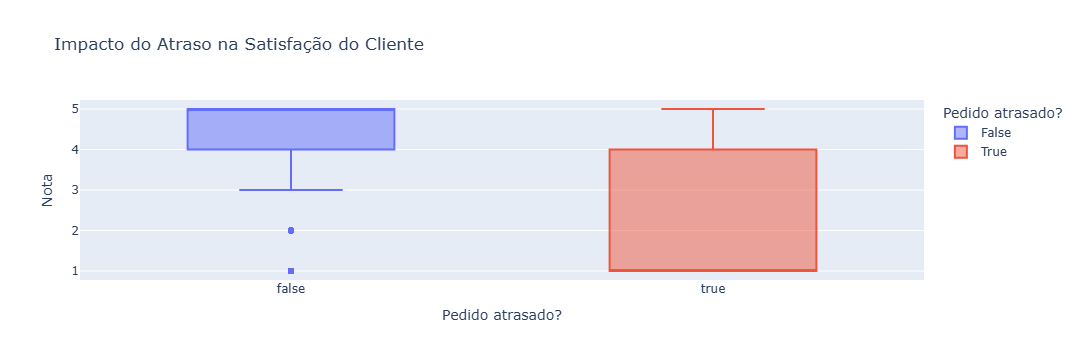

Exportado: (99441, 12)
Caminho: D:/DIVERSOS/Cases_Portfolio/DadosOlist/processed/dashboard_data.csv

Primeiras linhas do CSV para conferência:
                           order_id                       customer_id customer_state customer_city    lat    lng  review_score  delivery_days  delay_days  is_late order_status order_purchase_timestamp
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d             SP     sao paulo -23.58 -46.59             4              8          -8    False    delivered      2017-10-02 10:56:33
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef             BA     barreiras -12.18 -44.66             4             13          -6    False    delivered      2018-07-24 20:41:37
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089             GO    vianopolis -16.75 -48.51             5              9         -18    False    delivered      2018-08-08 08:38:49


In [1]:
# %% [markdown]
# # Olist Geolocation Analytics
# Análise end-to-end da distribuição geográfica de clientes e vendedores da Olist.

# %% [markdown]
# ### Bloco 1 — Imports e configuração

# %%
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import unicodedata
import warnings
warnings.filterwarnings("ignore")

# Configuração global
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

BASE = "D:/DIVERSOS/Cases_Portfolio/DadosOlist/DadosOriginal/"
OUT  = "D:/DIVERSOS/Cases_Portfolio/DadosOlist/processed/"


# %% [markdown]
# ### Bloco 2 — Carregamento dos dados

# %%
geo       = pd.read_csv(BASE + "olist_geolocation_dataset.csv",   encoding="utf-8")
customers = pd.read_csv(BASE + "olist_customers_dataset.csv",     encoding="utf-8")
orders    = pd.read_csv(BASE + "olist_orders_dataset.csv",        encoding="utf-8")
reviews   = pd.read_csv(BASE + "olist_order_reviews_dataset.csv", encoding="utf-8")

for name, df in [("geo", geo), ("customers", customers),
                 ("orders", orders), ("reviews", reviews)]:
    print(f"{name:10s} shape={df.shape}  cols={df.columns.tolist()}")


# %% [markdown]
# ### Bloco 3 — EDA rápida (entender antes de mexer)

# %%
for name, df in [("geo", geo), ("customers", customers),
                 ("orders", orders), ("reviews", reviews)]:
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    print(f"\n--- {name} ---")
    print(nulos if len(nulos) else "Sem nulos")


# %% [markdown]
# ### Bloco 4 — Limpeza e agregação da geolocalização

# %%
def normalize_city(city):
    city = str(city).lower().strip()
    city = unicodedata.normalize("NFKD", city).encode("ASCII", "ignore").decode("ASCII")
    return city

geo["geolocation_city"] = geo["geolocation_city"].apply(normalize_city)

geo_agg = geo.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "mean"),
    lng=("geolocation_lng", "mean"),
    city=("geolocation_city", "first"),
    state=("geolocation_state", "first")
).reset_index()

print(f"CEPs únicos: {len(geo_agg)}")
print(geo_agg.head())


# %% [markdown]
# ### Bloco 5 — Merge: clientes × geolocalização

# %%
customers["customer_zip_code_prefix"] = customers["customer_zip_code_prefix"].astype(int)
geo_agg["geolocation_zip_code_prefix"] = geo_agg["geolocation_zip_code_prefix"].astype(int)

customers_geo = customers.merge(
    geo_agg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

print(f"Linhas: {len(customers_geo)}")
print(f"Sem geolocalização: {customers_geo['lat'].isna().sum()}")
print(customers_geo.head())


# %% [markdown]
# ### Bloco 6 — Enriquecer pedidos: geo + reviews + delivery_days

# %%
# 1) Pedidos + dados geográficos do cliente
orders_geo = orders.merge(
    customers_geo[["customer_id", "customer_state", "customer_city", "lat", "lng"]],
    on="customer_id",
    how="left"
)

# 2) + reviews (remover duplicatas de order_id antes do merge)
reviews_dedup = reviews.drop_duplicates(subset=["order_id"], keep="first")
orders_geo = orders_geo.merge(
    reviews_dedup[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# 3) Converter datas
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for c in date_cols:
    orders_geo[c] = pd.to_datetime(orders_geo[c], errors="coerce")

# 4) Calcular tempo de entrega e atraso
orders_geo["delivery_days"] = (
    orders_geo["order_delivered_customer_date"] - orders_geo["order_purchase_timestamp"]
).dt.days

orders_geo["delay_days"] = (
    orders_geo["order_delivered_customer_date"] - orders_geo["order_estimated_delivery_date"]
).dt.days

orders_geo["is_late"] = orders_geo["delay_days"] > 0

print(f"Pedidos: {len(orders_geo)}")
print(f"Entregues: {orders_geo['delivery_days'].notna().sum()}")
print(f"Atrasados: {orders_geo['is_late'].sum()}")


# %% [markdown]
# ### Bloco 7 — Análises com Plotly

# %% [markdown]
# ##### 7.1 Mapa de dispersão — onde estão os clientes

# %%
sample = orders_geo.dropna(subset=["lat", "lng"]).sample(10000, random_state=42)

fig = px.scatter_mapbox(
    sample, lat="lat", lon="lng",
    color="review_score",
    color_continuous_scale="RdYlGn",
    opacity=0.6, zoom=3,
    mapbox_style="carto-positron",
    title="Distribuição de Clientes por Nota de Avaliação"
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()


# %% [markdown]
# ##### 7.2 Top 10 estados — volume + tempo médio de entrega

# %%
by_state = (
    orders_geo.dropna(subset=["delivery_days"])
    .groupby("customer_state")
    .agg(pedidos=("order_id", "count"),
         entrega_media=("delivery_days", "mean"),
         nota_media=("review_score", "mean"))
    .reset_index()
    .sort_values("pedidos", ascending=False)
    .head(10)
)

fig = px.bar(
    by_state, x="customer_state", y="pedidos",
    color="entrega_media", color_continuous_scale="Reds",
    title="Top 10 Estados — Volume de Pedidos vs Tempo Médio de Entrega (dias)"
)
fig.show()


# %% [markdown]
# ##### 7.3 Atraso vs satisfação — o insight que fecha o case

# %%
df_box = orders_geo.dropna(subset=["delay_days", "review_score", "is_late"]).copy()

fig = px.box(
    df_box,
    x="is_late", y="review_score",
    color="is_late",
    category_orders={"is_late": [False, True]},
    labels={"is_late": "Pedido atrasado?", "review_score": "Nota"},
    title="Impacto do Atraso na Satisfação do Cliente"
)
fig.show()


# %% [markdown]
# ### Bloco 8 — Exportar dados enriquecidos para o Power BI

# %%
# %% [markdown]
# ### Bloco 8 — Exportar dados enriquecidos para o Power BI

# %%
import os

dashboard_data = orders_geo[[
    "order_id", "customer_id", "customer_state", "customer_city",
    "lat", "lng", "review_score", "delivery_days", "delay_days",
    "is_late", "order_status", "order_purchase_timestamp"
]].copy()

# ---------------------------------------------------------------
# 1) Forçar colunas inteiras como Int64 (sem ".0")
#    Isso impede que 5 vire "5.0" no CSV (que o Power BI leria como 50)
# ---------------------------------------------------------------
for col in ["review_score", "delivery_days", "delay_days"]:
    dashboard_data[col] = pd.to_numeric(dashboard_data[col], errors="coerce").astype("Int64")

# ---------------------------------------------------------------
# 2) Arredondar lat/lng para 6 casas (evita ruído de precisão)
# ---------------------------------------------------------------
dashboard_data["lat"] = pd.to_numeric(dashboard_data["lat"], errors="coerce").round(6)
dashboard_data["lng"] = pd.to_numeric(dashboard_data["lng"], errors="coerce").round(6)

# ---------------------------------------------------------------
# 3) Exportar com decimal="," → formato brasileiro
#    Float vira "-23,55" (Power BI pt-BR lê certo)
#    Inteiro vira "5" (Power BI pt-BR lê certo)
# ---------------------------------------------------------------
os.makedirs(OUT, exist_ok=True)
dashboard_data.to_csv(
    OUT + "dashboard_data.csv",
    index=False,
    encoding="utf-8",
    decimal=","
)

print(f"Exportado: {dashboard_data.shape}")
print(f"Caminho: {OUT}dashboard_data.csv")
print("\nPrimeiras linhas do CSV para conferência:")
print(dashboard_data.head(3).to_string())